# Exercício sobre regressão com DNN e dados ruidosos

Treine uma rede neural que se ajuste aos dados fornecidos abaixo.

Use o modelo mais simples possível, mas que se ajuste bem aos dados.

### Importando as bibliotecas

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Deixa o resultado reproduzivel
tf.keras.utils.set_random_seed(42)


### Definindo o dataset

In [2]:
# Atributo.
x = np.array([[-1.0000],[-0.9800],[-0.9600],[-0.9400],[-0.9200],[-0.9000],[-0.8800],[-0.8600],[-0.8400],[-0.8200],[-0.8000],[-0.7800],[-0.7600],[-0.7400],[-0.7200],[-0.7000],[-0.6800],[-0.6600],[-0.6400],[-0.6200],[-0.6000],[-0.5800],[-0.5600],[-0.5400],[-0.5200],[-0.5000],[-0.4800],[-0.4600],[-0.4400],[-0.4200],[-0.4000],[-0.3800],[-0.3600],[-0.3400],[-0.3200],[-0.3000],[-0.2800],[-0.2600],[-0.2400],[-0.2200],[-0.2000],[-0.1800],[-0.1600],[-0.1400],[-0.1200],[-0.1000],[-0.0800],[-0.0600],[-0.0400],[-0.0200],[0.0000],[0.0200],[0.0400],[0.0600],[0.0800],[0.1000],[0.1200],[0.1400],[0.1600],[0.1800],[0.2000],[0.2200],[0.2400],[0.2600],[0.2800],[0.3000],[0.3200],[0.3400],[0.3600],[0.3800],[0.4000],[0.4200],[0.4400],[0.4600],[0.4800],[0.5000],[0.5200],[0.5400],[0.5600],[0.5800],[0.6000],[0.6200],[0.6400],[0.6600],[0.6800],[0.7000],[0.7200],[0.7400],[0.7600],[0.7800],[0.8000],[0.8200],[0.8400],[0.8600],[0.8800],[0.9000],[0.9200],[0.9400],[0.9600],[0.9800]])
x = x.reshape((len(x), ))

# Valores esperados (rótulos).
y = np.array([[2.8430],[3.1381],[2.9244],[2.7861],[2.9280],[2.7738],[2.8377],[2.7283],[2.9339],[2.8179],[2.9297],[2.9174],[2.9368],[2.6965],[2.4980],[2.6416],[2.4662],[2.7446],[2.8236],[2.5448],[2.5921],[2.6842],[2.2680],[2.5057],[2.4570],[2.4846],[2.6486],[2.5413],[2.3897],[2.4596],[2.2950],[2.2857],[2.4995],[2.4205],[2.3266],[2.2281],[2.3636],[2.2785],[2.1923],[2.2687],[2.1807],[2.1150],[2.2315],[2.0983],[2.0559],[2.0267],[2.0947],[1.9915],[2.0493],[2.0690],[2.1200],[1.9080],[1.9794],[1.9558],[1.7788],[1.9183],[1.9108],[1.8345],[1.8798],[1.8059],[1.9824],[1.7402],[1.6944],[1.6580],[1.6566],[1.5599],[1.5479],[1.4707],[1.6614],[1.7665],[1.5337],[1.3794],[1.4164],[1.7335],[1.5664],[1.4243],[1.5442],[1.3090],[1.4028],[1.3816],[1.6266],[1.4310],[1.4552],[1.4960],[1.2963],[1.2333],[1.2134],[1.2729],[1.2125],[1.2815],[1.1458],[0.9575],[1.3239],[1.1006],[1.0718],[1.0081],[1.0699],[0.9018],[1.1268],[0.9014]])
y = y.reshape((len(y), ))

### Plotando o conjunto de dados.

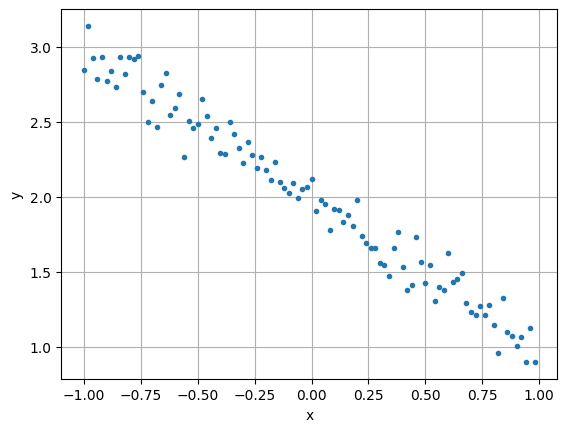

In [3]:
plt.plot(x, y, '.')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

### Definina a rede neural

In [4]:
# Cria um modelo simples para regressao
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1)
])


### Imprima o resumo da arquitetura do modelo

In [5]:
# Mostra a arquitetura do modelo
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

### Compile o modelo

In [6]:
# Compila o modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.05),
    loss='mean_squared_error',
    metrics=['mae']
)


### Treine o modelo

In [7]:
# Treina o modelo
history = model.fit(
    x,
    y,
    epochs=300,
    verbose=0
)

# Mostra o erro final
loss, mae = model.evaluate(x, y, verbose=0)

print('MSE final:', loss)
print('MAE final:', mae)


MSE final: 0.011233457364141941
MAE final: 0.08402428030967712


### Plote o histórico de erros ao longo das épocas de treinamento

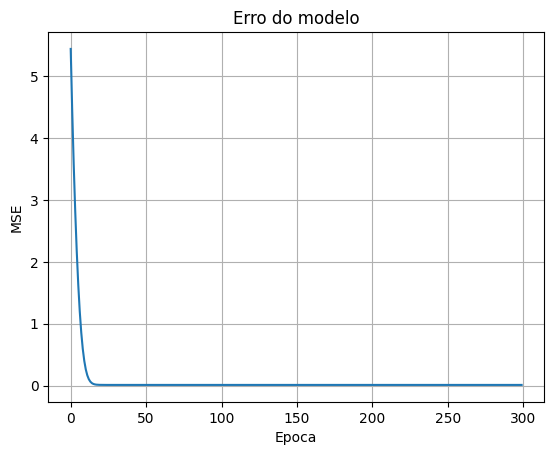

In [8]:
# Plota o erro ao longo do treinamento
plt.plot(history.history['loss'])
plt.title('Erro do modelo')
plt.ylabel('MSE')
plt.xlabel('Epoca')
plt.grid()
plt.show()


### Compare os dados ruidosos com as predições feitas pelo modelo.

w = -0.99832803
b = 1.9779679


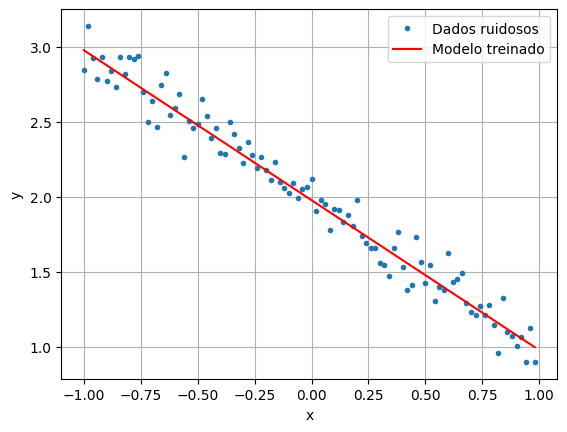

In [9]:
# Faz as predicoes com o modelo treinado
y_predito = model.predict(x, verbose=0)

# Mostra os pesos aprendidos
w = model.get_weights()[0][0][0]
b = model.get_weights()[1][0]

print('w =', w)
print('b =', b)

# Compara os dados ruidosos com a reta aprendida
plt.plot(x, y, '.', label='Dados ruidosos')
plt.plot(x, y_predito, 'r-', label='Modelo treinado')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()
